### TP 4

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score, roc_auc_score, confusion_matrix, roc_curve

# Cargar base original desde tu ruta
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta")

# Crear la variable binaria
df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 2 else 0)

# Filtrar por año
df_2004 = df[df['ano4'] == 2004]
df_2024 = df[df['ano4'] == 2024]

# Función de split
def split_data(df):
    X = df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']]
    y = df['desocupado']
    return train_test_split(X, y, test_size=0.3, random_state=444)

# Split para 2004
X_train_2004, X_test_2004, y_train_2004, y_test_2004 = split_data(df_2004)

# Split para 2024
X_train_2024, X_test_2024, y_train_2024, y_test_2024 = split_data(df_2024)


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_76257/676620141.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 2 else 0)


In [7]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score
from sklearn.model_selection import train_test_split

# --- Imputar faltantes con la media ---
imputer = SimpleImputer(strategy='mean')
X_train_2004_imputed = pd.DataFrame(imputer.fit_transform(X_train_2004), columns=X_train_2004.columns)
X_test_2004_imputed = pd.DataFrame(imputer.transform(X_test_2004), columns=X_test_2004.columns)

# --- Definir modelos ---
model_lasso = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=444)
model_ridge = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, random_state=444)

# --- Entrenar modelos ---
model_lasso.fit(X_train_2004_imputed, y_train_2004)
model_ridge.fit(X_train_2004_imputed, y_train_2004)

# --- Predicciones ---
pred_lasso = model_lasso.predict(X_test_2004_imputed)
proba_lasso = model_lasso.predict_proba(X_test_2004_imputed)[:, 1]

pred_ridge = model_ridge.predict(X_test_2004_imputed)
proba_ridge = model_ridge.predict_proba(X_test_2004_imputed)[:, 1]

# --- Métricas ---
print("=== LASSO ===")
print("Accuracy:", round(accuracy_score(y_test_2004, pred_lasso), 3))
print("AUC:", round(roc_auc_score(y_test_2004, proba_lasso), 3))
print("Coeficientes:")
print(pd.Series(model_lasso.coef_[0], index=X_train_2004.columns).round(3))

print("\n=== RIDGE ===")
print("Accuracy:", round(accuracy_score(y_test_2004, pred_ridge), 3))
print("AUC:", round(roc_auc_score(y_test_2004, proba_ridge), 3))
print("Coeficientes:")
print(pd.Series(model_ridge.coef_[0], index=X_train_2004.columns).round(3))

=== LASSO ===
Accuracy: 0.966
AUC: 0.599
Coeficientes:
edad_cuad              -0.001
experiencia_pot        -0.028
edad_x_exp              0.001
log_ing                -0.296
ingreso_sin_subsidio    0.000
anos_educacion          0.023
dtype: float64

=== RIDGE ===
Accuracy: 0.966
AUC: 0.561
Coeficientes:
edad_cuad              -0.006
experiencia_pot        -0.041
edad_x_exp              0.007
log_ing                -0.062
ingreso_sin_subsidio    0.000
anos_educacion         -0.004
dtype: float64


Matriz de confusión - LASSO:
 [[564   0]
 [ 20   0]]
Matriz de confusión - Ridge:
 [[564   0]
 [ 20   0]]


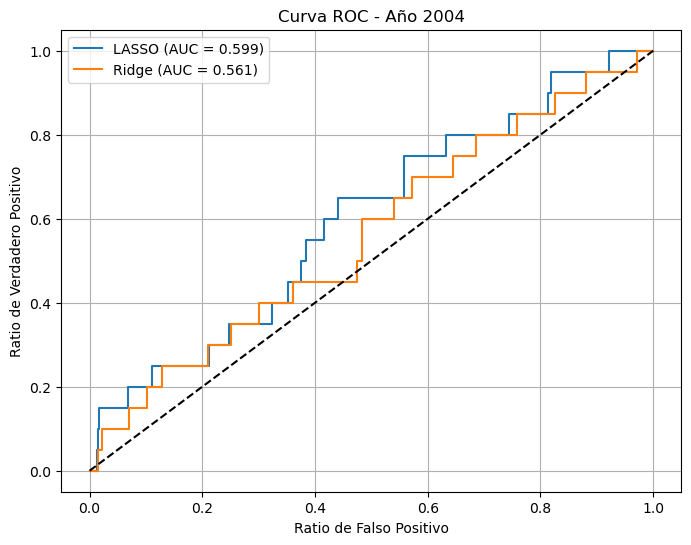

In [13]:
from sklearn.metrics import confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# === MATRICES DE CONFUSIÓN ===
cm_lasso = confusion_matrix(y_test_2004, pred_lasso)
cm_ridge = confusion_matrix(y_test_2004, pred_ridge)

print("Matriz de confusión - LASSO:\n", cm_lasso)
print("Matriz de confusión - Ridge:\n", cm_ridge)

# === CURVAS ROC ===
fpr_lasso, tpr_lasso, _ = roc_curve(y_test_2004, proba_lasso)
fpr_ridge, tpr_ridge, _ = roc_curve(y_test_2004, proba_ridge)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso, tpr_lasso, label=f"LASSO (AUC = {roc_auc_score(y_test_2004, proba_lasso):.3f})")
plt.plot(fpr_ridge, tpr_ridge, label=f"Ridge (AUC = {roc_auc_score(y_test_2004, proba_ridge):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Ratio de Falso Positivo")
plt.ylabel("Ratio de Verdadero Positivo")
plt.title("Curva ROC - Año 2004")
plt.legend()
plt.grid(True)
plt.show()


=== LASSO 2024 ===
Accuracy: 0.977
AUC: 0.804
Coeficientes:
edad_cuad              -0.001
experiencia_pot         0.055
edad_x_exp             -0.000
log_ing                -0.295
ingreso_sin_subsidio   -0.000
anos_educacion          0.016
dtype: float64

=== RIDGE 2024 ===
Accuracy: 0.977
AUC: 0.726
Coeficientes:
edad_cuad              -0.010
experiencia_pot        -0.002
edad_x_exp              0.010
log_ing                -0.006
ingreso_sin_subsidio   -0.000
anos_educacion         -0.005
dtype: float64

Matriz de confusión - LASSO:
 [[887   0]
 [ 21   0]]
Matriz de confusión - Ridge:
 [[887   0]
 [ 21   0]]


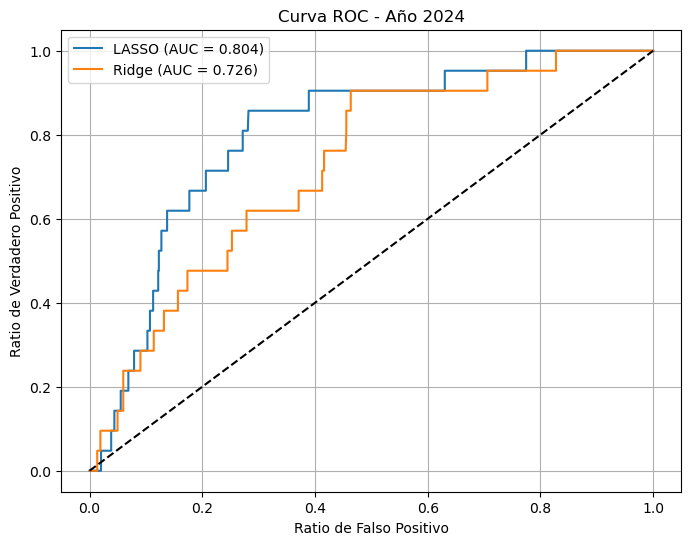

In [15]:
# --- Imputar faltantes con la media ---
X_train_2024_imputed = pd.DataFrame(imputer.fit_transform(X_train_2024), columns=X_train_2024.columns)
X_test_2024_imputed = pd.DataFrame(imputer.transform(X_test_2024), columns=X_test_2024.columns)

# --- Definir modelos ---
model_lasso_2024 = LogisticRegression(penalty='l1', solver='liblinear', C=1.0, random_state=444)
model_ridge_2024 = LogisticRegression(penalty='l2', solver='liblinear', C=1.0, random_state=444)

# --- Entrenar ---
model_lasso_2024.fit(X_train_2024_imputed, y_train_2024)
model_ridge_2024.fit(X_train_2024_imputed, y_train_2024)

# --- Predicciones y probabilidades ---
pred_lasso_2024 = model_lasso_2024.predict(X_test_2024_imputed)
proba_lasso_2024 = model_lasso_2024.predict_proba(X_test_2024_imputed)[:, 1]

pred_ridge_2024 = model_ridge_2024.predict(X_test_2024_imputed)
proba_ridge_2024 = model_ridge_2024.predict_proba(X_test_2024_imputed)[:, 1]

# --- Métricas ---
print("=== LASSO 2024 ===")
print("Accuracy:", round(accuracy_score(y_test_2024, pred_lasso_2024), 3))
print("AUC:", round(roc_auc_score(y_test_2024, proba_lasso_2024), 3))
print("Coeficientes:")
print(pd.Series(model_lasso_2024.coef_[0], index=X_train_2024.columns).round(3))

print("\n=== RIDGE 2024 ===")
print("Accuracy:", round(accuracy_score(y_test_2024, pred_ridge_2024), 3))
print("AUC:", round(roc_auc_score(y_test_2024, proba_ridge_2024), 3))
print("Coeficientes:")
print(pd.Series(model_ridge_2024.coef_[0], index=X_train_2024.columns).round(3))

# --- MATRICES DE CONFUSIÓN ---
cm_lasso_2024 = confusion_matrix(y_test_2024, pred_lasso_2024)
cm_ridge_2024 = confusion_matrix(y_test_2024, pred_ridge_2024)

print("\nMatriz de confusión - LASSO:\n", cm_lasso_2024)
print("Matriz de confusión - Ridge:\n", cm_ridge_2024)

# --- CURVAS ROC ---
fpr_lasso_2024, tpr_lasso_2024, _ = roc_curve(y_test_2024, proba_lasso_2024)
fpr_ridge_2024, tpr_ridge_2024, _ = roc_curve(y_test_2024, proba_ridge_2024)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lasso_2024, tpr_lasso_2024, label=f"LASSO (AUC = {roc_auc_score(y_test_2024, proba_lasso_2024):.3f})")
plt.plot(fpr_ridge_2024, tpr_ridge_2024, label=f"Ridge (AUC = {roc_auc_score(y_test_2024, proba_ridge_2024):.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Ratio de Falso Positivo")
plt.ylabel("Ratio de Verdadero Positivo")
plt.title("Curva ROC - Año 2024")
plt.legend()
plt.grid(True)
plt.show()


In [19]:
#Hacemos los valores del TP3 nuevamente (porque queremos imputar la media)
from sklearn.linear_model import LogisticRegression

# --- Modelo sin penalización para 2004 ---
logit_nopenalty_2004 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=444)
logit_nopenalty_2004.fit(X_train_2004_imputed, y_train_2004)
pred_np_2004 = logit_nopenalty_2004.predict(X_test_2004_imputed)
proba_np_2004 = logit_nopenalty_2004.predict_proba(X_test_2004_imputed)[:, 1]

# --- Modelo sin penalización para 2024 ---
logit_nopenalty_2024 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000, random_state=444)
logit_nopenalty_2024.fit(X_train_2024_imputed, y_train_2024)
pred_np_2024 = logit_nopenalty_2024.predict(X_test_2024_imputed)
proba_np_2024 = logit_nopenalty_2024.predict_proba(X_test_2024_imputed)[:, 1]

# --- Métricas ---
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

print("=== 2004: Logistic Regression sin penalización ===")
print("Accuracy:", round(accuracy_score(y_test_2004, pred_np_2004), 3))
print("AUC:", round(roc_auc_score(y_test_2004, proba_np_2004), 3))
print("Matriz de confusión:\n", confusion_matrix(y_test_2004, pred_np_2004))

print("\n=== 2024: Logistic Regression sin penalización ===")
print("Accuracy:", round(accuracy_score(y_test_2024, pred_np_2024), 3))
print("AUC:", round(roc_auc_score(y_test_2024, proba_np_2024), 3))
print("Matriz de confusión:\n", confusion_matrix(y_test_2024, pred_np_2024))



=== 2004: Logistic Regression sin penalización ===
Accuracy: 0.966
AUC: 0.667
Matriz de confusión:
 [[564   0]
 [ 20   0]]

=== 2024: Logistic Regression sin penalización ===
Accuracy: 0.977
AUC: 0.816
Matriz de confusión:
 [[887   0]
 [ 21   0]]


Punto 4

In [23]:
import numpy as np
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import mean_squared_error

# Crear vector de valores de lambda como potencias de 10, y su inverso como Cs
lambdas = np.logspace(-5, 5, 11)     # λ = 10^n con n ∈ [-5, ..., 5]
Cs = 1 / lambdas                     # Porque C = 1/λ en scikit-learn

# Cross-validation para LASSO
logit_lasso_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=10,
    penalty='l1',
    solver='liblinear',
    scoring='neg_mean_squared_error',
    max_iter=1000,
    random_state=444
)
logit_lasso_cv.fit(X_train_2004_imputed, y_train_2004)

# Cross-validation para Ridge
logit_ridge_cv = LogisticRegressionCV(
    Cs=Cs,
    cv=10,
    penalty='l2',
    solver='liblinear',
    scoring='neg_mean_squared_error',
    max_iter=1000,
    random_state=444
)
logit_ridge_cv.fit(X_train_2004_imputed, y_train_2004)

# Obtener MSEs promedios por C para graficar
mse_lasso = -np.mean(logit_lasso_cv.scores_[1], axis=0)
mse_ridge = -np.mean(logit_ridge_cv.scores_[1], axis=0)

# Proporción de coeficientes en cero para LASSO por cada C
coef_zero_ratio = []
for c in Cs:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=1000, random_state=444)
    model.fit(X_train_2004_imputed, y_train_2004)
    coef_zero_ratio.append(np.mean(model.coef_ == 0))

# Valor óptimo de λ (C óptimo)
lambda_opt_lasso = 1 / logit_lasso_cv.C_[0]
lambda_opt_ridge = 1 / logit_ridge_cv.C_[0]

(lambda_opt_lasso, lambda_opt_ridge, mse_lasso, mse_ridge, coef_zero_ratio)


(1e-05,
 1e-05,
 array([0.1262559, 0.1262559, 0.1262559, 0.1262559, 0.1262559, 0.1262559,
        0.1262559, 0.1262559, 0.1262559, 0.1262559, 0.1262559]),
 array([0.1262559, 0.1262559, 0.1262559, 0.1262559, 0.1262559, 0.1262559,
        0.1262559, 0.1262559, 0.1262559, 0.1262559, 0.1262559]),
 [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.3333333333333333,
  0.5,
  0.6666666666666666,
  0.6666666666666666])

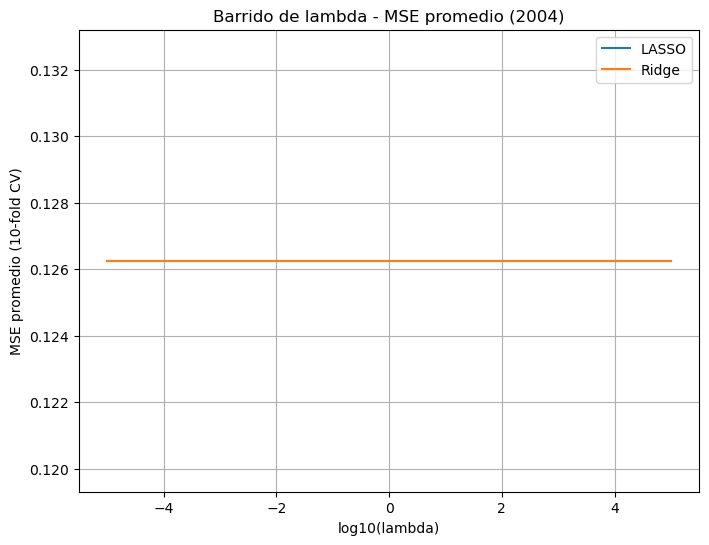

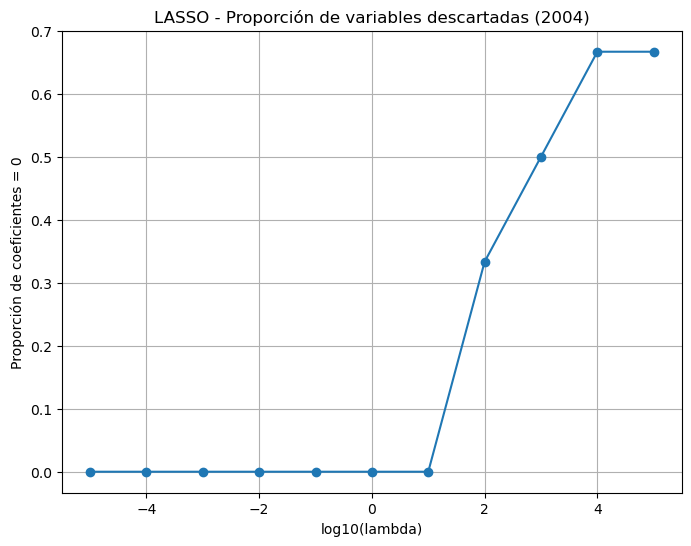

In [25]:
# Graficar MSE vs lambda (log scale)
plt.figure(figsize=(8, 6))
plt.plot(np.log10(lambdas), mse_lasso, label="LASSO")
plt.plot(np.log10(lambdas), mse_ridge, label="Ridge")
plt.xlabel("log10(lambda)")
plt.ylabel("MSE promedio (10-fold CV)")
plt.title("Barrido de lambda - MSE promedio (2004)")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de proporción de coeficientes en cero (LASSO)
plt.figure(figsize=(8, 6))
plt.plot(np.log10(lambdas), coef_zero_ratio, marker='o')
plt.xlabel("log10(lambda)")
plt.ylabel("Proporción de coeficientes = 0")
plt.title("LASSO - Proporción de variables descartadas (2004)")
plt.grid(True)
plt.show()


In [27]:
# Repetimos el análisis para el año 2024

# Cross-validation para LASSO (2024)
logit_lasso_cv_2024 = LogisticRegressionCV(
    Cs=Cs,
    cv=10,
    penalty='l1',
    solver='liblinear',
    scoring='neg_mean_squared_error',
    max_iter=1000,
    random_state=444
)
logit_lasso_cv_2024.fit(X_train_2024_imputed, y_train_2024)

# Cross-validation para Ridge (2024)
logit_ridge_cv_2024 = LogisticRegressionCV(
    Cs=Cs,
    cv=10,
    penalty='l2',
    solver='liblinear',
    scoring='neg_mean_squared_error',
    max_iter=1000,
    random_state=444
)
logit_ridge_cv_2024.fit(X_train_2024_imputed, y_train_2024)

# Obtener MSEs promedios
mse_lasso_2024 = -np.mean(logit_lasso_cv_2024.scores_[1], axis=0)
mse_ridge_2024 = -np.mean(logit_ridge_cv_2024.scores_[1], axis=0)

# Proporción de coeficientes en cero (LASSO)
coef_zero_ratio_2024 = []
for c in Cs:
    model = LogisticRegression(penalty='l1', solver='liblinear', C=c, max_iter=1000, random_state=444)
    model.fit(X_train_2024_imputed, y_train_2024)
    coef_zero_ratio_2024.append(np.mean(model.coef_ == 0))

# λ óptimo
lambda_opt_lasso_2024 = 1 / logit_lasso_cv_2024.C_[0]
lambda_opt_ridge_2024 = 1 / logit_ridge_cv_2024.C_[0]

(lambda_opt_lasso_2024, lambda_opt_ridge_2024, mse_lasso_2024, mse_ridge_2024, coef_zero_ratio_2024)


(1e-05,
 1e-05,
 array([0.06234463, 0.06234463, 0.06234463, 0.06234463, 0.06234463,
        0.06234463, 0.06234463, 0.06234463, 0.06234463, 0.06234463,
        0.06234463]),
 array([0.06234463, 0.06234463, 0.06234463, 0.06234463, 0.06234463,
        0.06234463, 0.06234463, 0.06234463, 0.06234463, 0.06234463,
        0.06234463]),
 [0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.0,
  0.16666666666666666,
  0.3333333333333333,
  0.5,
  0.6666666666666666,
  0.6666666666666666])

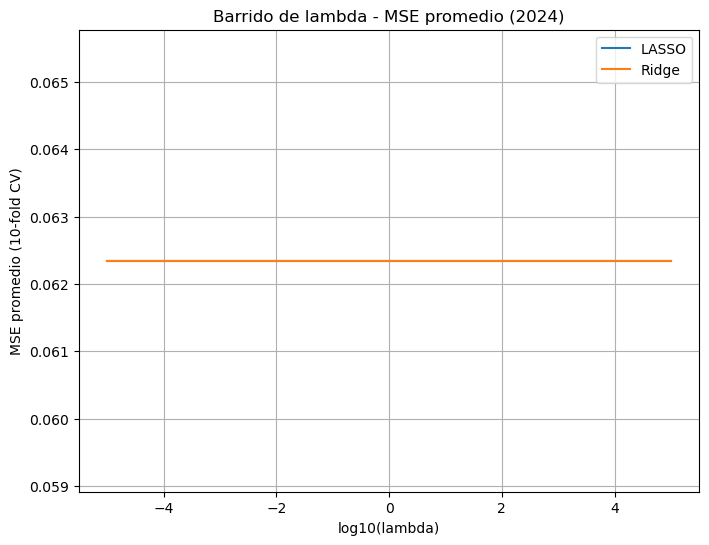

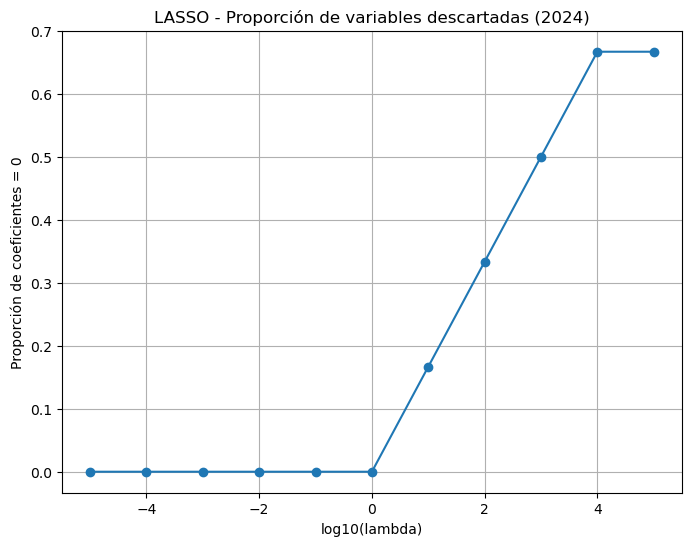

In [29]:
# Gráfico MSE vs lambda para 2024
plt.figure(figsize=(8, 6))
plt.plot(np.log10(lambdas), mse_lasso_2024, label="LASSO")
plt.plot(np.log10(lambdas), mse_ridge_2024, label="Ridge")
plt.xlabel("log10(lambda)")
plt.ylabel("MSE promedio (10-fold CV)")
plt.title("Barrido de lambda - MSE promedio (2024)")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de proporción de coeficientes en cero (LASSO 2024)
plt.figure(figsize=(8, 6))
plt.plot(np.log10(lambdas), coef_zero_ratio_2024, marker='o')
plt.xlabel("log10(lambda)")
plt.ylabel("Proporción de coeficientes = 0")
plt.title("LASSO - Proporción de variables descartadas (2024)")
plt.grid(True)
plt.show()


Punto 5

In [34]:
from sklearn.linear_model import LogisticRegression
import pandas as pd

# C correspondiente a lambda = 10^-5
C_opt = 1e5

# Ajuste para 2004
lasso_2004 = LogisticRegression(penalty='l1', solver='liblinear', C=C_opt, max_iter=1000)
lasso_2004.fit(X_train_2004_imputed, y_train_2004)

np_2004 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
np_2004.fit(X_train_2004_imputed, y_train_2004)

# Ajuste para 2024
lasso_2024 = LogisticRegression(penalty='l1', solver='liblinear', C=C_opt, max_iter=1000)
lasso_2024.fit(X_train_2024_imputed, y_train_2024)

np_2024 = LogisticRegression(penalty=None, solver='lbfgs', max_iter=1000)
np_2024.fit(X_train_2024_imputed, y_train_2024)

# Crear DataFrames de coeficientes
coef_2004 = pd.DataFrame({
    'Variable': X_train_2004_imputed.columns,
    'LASSO': lasso_2004.coef_[0],
    'TP3 (sin penalización)': np_2004.coef_[0]
}).set_index('Variable')

coef_2024 = pd.DataFrame({
    'Variable': X_train_2024_imputed.columns,
    'LASSO': lasso_2024.coef_[0],
    'TP3 (sin penalización)': np_2024.coef_[0]
}).set_index('Variable')

# Tabla combinada
coef_todos = pd.concat({"2004": coef_2004, "2024": coef_2024}, axis=1)

# Mostrar tabla
coef_todos



2004                             2024  \
                         LASSO TP3 (sin penalización)     LASSO   
Variable                                                          
edad_cuad            -0.001069              -0.003270 -0.000647   
experiencia_pot      -0.028200              -0.002667  0.103355   
edad_x_exp            0.001255               0.003430 -0.000957   
log_ing              -1.235257              -1.601650 -0.390712   
ingreso_sin_subsidio  0.000002               0.000003 -0.000009   
anos_educacion        0.036137               0.074868  0.031935   

                                             
                     TP3 (sin penalización)  
Variable                                     
edad_cuad                         -0.000824  
experiencia_pot                    0.115948  
edad_x_exp                        -0.000913  
log_ing                           -0.384266  
ingreso_sin_subsidio              -0.000009  
anos_educacion                     0.044209